**Neural Network Fundamentals and Training Behavior Analysis**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam, Nadam

**Task 1: Dataset Understanding**

Number of rows: 2000 
Number of columns: 17

Type of input features: 
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Target variable description (Churn): 
count    2000.000000
mean        0.015500
std         0.123561
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: churn, dtype: float64



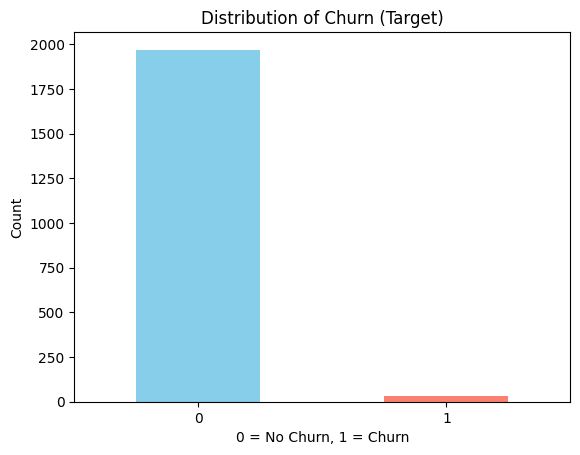

In [3]:
# Load the dataset
df = pd.read_csv('customer_churn_nn.csv')

# Number of rows and columns
print(f"Number of rows: {df.shape[0]} \nNumber of columns: {df.shape[1]}")

# Type of input features
print(f"\nType of input features: \n{df.dtypes}")

# Target variable description
# In this supervised learning task, 'churn' is our target.
# It is a binary classification target (0 = Stayed, 1 = Left)
print(f"\nTarget variable description (Churn): \n{df['churn'].describe()}")

# Missing value check
print(f"\nMissing value check: \n{df.isnull().sum()}")

# Basic statistical summary
print(f"\nBasic statistical summary: \n{df.describe()}")

# Distribution of the target variable
print("\nDistribution of the target variable:")
churn_counts = df['churn'].value_counts()
print(churn_counts)

# Visualize the distribution of the target variable
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Churn (Target)')
plt.xlabel('0 = No Churn, 1 = Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Task 2: Data Preprocessing**

In [6]:
# Prepare the data for neural network training

# Handling missing values
# Based on Task 1, we have 0 missing values.
# We run this code to confirm that there are no missing values before proceeding.
df = df.dropna()  

# Encoding categorical columns
# We also drop 'customer_id' as it's just a random label, not a "clue"
X = df.drop(['churn', 'customer_id'], axis=1)
X = pd.get_dummies(X, drop_first=True)  # One-hot encoding for categorical variables
y = df['churn']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling or normalizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"--- Data Preprocessing Completed ---")
print(f"Features after encoding: {X.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

--- Data Preprocessing Completed ---
Features after encoding: 24
Training samples: 1600
Testing samples: 400


**Task 3: Neural Network Model Building**

In [13]:
# We use the 'Sequential' model from Keras to build our neural network
model = Sequential()

# Input layer and first hidden layer with 16 neurons and ReLU activation
model.add(Dense(units=16, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer with 8 neurons and ReLU activation
model.add(Dense(units=8, activation='relu'))

# Output layer with 1 neuron and sigmoid activation for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# Compile the Model 
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the architecture of the model
print("\n--- Model Architecture ---")
model.summary()



--- Model Architecture ---


C:\Users\Mitali Kalburgi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Training and Evaluation**

In [14]:
# Training the model
# We train for 50 epochs with a batch size of 32
# validation_split=0.2 tells the model to test itself on 20% of the training data at the end of every epoch so we can watch the progress
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9867 - loss: 0.2245 - val_accuracy: 0.9781 - val_loss: 0.1845
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.1304 - val_accuracy: 0.9781 - val_loss: 0.1334
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0949 - val_accuracy: 0.9781 - val_loss: 0.1171
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0808 - val_accuracy: 0.9781 - val_loss: 0.1116
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0738 - val_accuracy: 0.9781 - val_loss: 0.1087
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0688 - val_accuracy: 0.9781 - val_loss: 0.1071
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0653 - val_accuracy: 0.9781 - val_loss: 0.1055
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0621 - val_accuracy: 0.9781 - val_loss:

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Training Accuracy: 99.30%

Training Loss: 0.0131

Testing Accuracy: 98.50%

Testing Loss: 0.1106


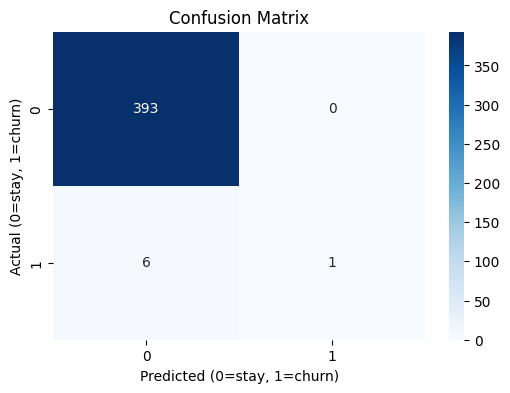


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       1.00      0.14      0.25         7

    accuracy                           0.98       400
   macro avg       0.99      0.57      0.62       400
weighted avg       0.99      0.98      0.98       400



In [15]:
# Evaluate the model

# Capture Training Metrics from the history object
final_train_accuracy = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]

# Testing Accuracy and Loss
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Generate Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary predictions

# Display Results
print(f"\nTraining Accuracy: {final_train_accuracy*100:.2f}%")
print(f"\nTraining Loss: {final_train_loss:.4f}")
print(f"\nTesting Accuracy: {test_accuracy*100:.2f}%")
print(f"\nTesting Loss: {test_loss:.4f}")

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### **Interpretation of Results**

* **High Accuracy vs. Low Sensitivity:** The model achieved a high **Testing Accuracy of 98.50%**. While this looks successful on paper, the **Confusion Matrix** reveals that the model only correctly identified **1 out of 7** actual churners. 
* **Recall Issues:** The **Recall for Class 1 (Churn) is 0.14**, meaning the model missed 86% of customers who actually left. This indicates that the model is biased toward the majority class (customers who stay) because it is the "easiest" way to minimize loss during training.
* **Precision Performance:** Interestingly, the **Precision for Class 1 is 1.00**, meaning that when the model *did* predict a churn, it was correct. The problem is not that the model is wrong, but that it is too "cautious" or "lazy" to make a churn prediction most of the time.
* **Conclusion:** The model is currently underperforming for the business goal of identifying churners. This baseline confirms that the dataset is highly imbalanced, and future experiments must focus on improving the **Recall** of the minority class (Class 1).

### **Important Note on Experimental Consistency**

During the development of this project, it was observed that re-running the training cells (`model.fit`) without re-initializing the model architecture leads to **Incremental Training**. This causes the model to retain weights from previous runs, resulting in fluctuating and artificially higher results.

To ensure scientific integrity and a "fair" comparison across experiments:
1. Each experiment begins by **re-initializing** the model architecture (re-running the `Sequential` block).
2. The model is trained and tested **only once** per configuration.
3. This ensures that the changes in performance are due to the **hyperparameters** themselves, not the accumulation of training time.

**Task 5: Hyperparameter Experimentation**

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Exp 1 Results -> Accuracy: 98.25%, Loss: 0.0912


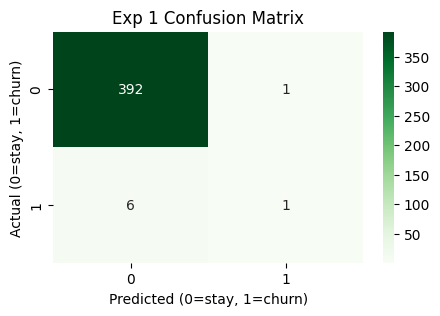

In [23]:
# Experiment 1: Activation & Batch Size
# Change: Switched activation to 'tanh' and reduced batch size to 16

model_exp1 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='tanh'),  # Changed from relu
    Dense(units=8, activation='tanh'),   # Changed from relu
    Dense(units=1, activation='sigmoid')
])
model_exp1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
history1 = model_exp1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,  
    validation_split=0.2,
    verbose=0
)

# Evaluation
test_loss1, test_accuracy1 = model_exp1.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred1 = (model_exp1.predict(X_test) > 0.5).astype(int)
print(f"Exp 1 Results -> Accuracy: {test_accuracy1*100:.2f}%, Loss: {test_loss1:.4f}")

# Visualize Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d', cmap='Greens')
plt.title('Exp 1 Confusion Matrix') 
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')  
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Exp 2 Results -> Accuracy: 98.00%, Loss: 0.0801


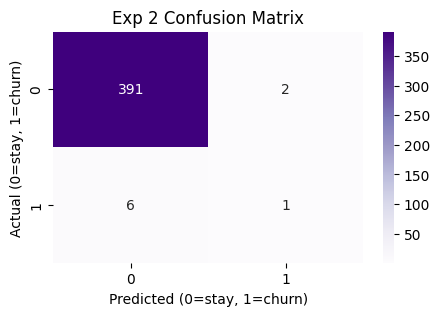

In [24]:
# Experiment 2 : Priority Training (Class Weights)
# Change: Added class_weight to force the model to prioritize the minority class

model_exp2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='relu'),
    Dense(units=8, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model_exp2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define weights
# This mathematically "punishes" the model 10x more for missing a churner.
custom_weights = {0: 1.0, 1: 10.0}

# Training with class weights
history2 = model_exp2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=custom_weights,  # Added class weights
    verbose=0
)

# Evaluation
test_loss2, test_accuracy2 = model_exp2.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred2 = (model_exp2.predict(X_test) > 0.5).astype(int)
print(f"Exp 2 Results -> Accuracy: {test_accuracy2*100:.2f}%, Loss: {test_loss2:.4f}")

# Visualize Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred2), annot=True, fmt='d', cmap='Purples')
plt.title('Exp 2 Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Experiment 3 Results:
Training Accuracy: 98.56%
Training Loss:     0.4622
Testing Accuracy:  95.00%
Testing Loss:      0.5655


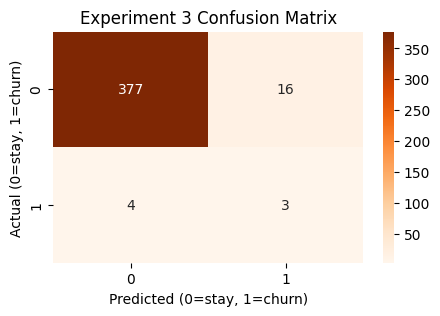


 Detailed Performance:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       393
           1       0.16      0.43      0.23         7

    accuracy                           0.95       400
   macro avg       0.57      0.69      0.60       400
weighted avg       0.97      0.95      0.96       400



In [27]:
# Experiment 3
# Changes: Extreme Class Weighting, Drastic Batch Size Reduction, Quadrupling the Epochs

model_exp3 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='tanh'),  # Changed from relu to tanh
    Dense(units=8, activation='tanh'),   # Changed from relu to tanh
    Dense(units=1, activation='sigmoid')
])

model_exp3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Extreme weights to force the model to prioritize the 7 churners
# We are telling the model Churners (1) are 50x more important than Stayers (0)
final_weights = {0: 1.0, 1: 50.0}

# Training
history3 = model_exp3.fit(
    X_train, y_train,
    epochs=200,  # Quadrupled from 50
    batch_size=8,  # Drastically reduced from 32
    class_weight=final_weights,  # Extreme class weights
    verbose=0
)

# Capture Training Metrics
training_accuracy3 = history3.history['accuracy'][-1]
training_loss3 = history3.history['loss'][-1]

# Evaluation
test_loss3, test_accuracy3 = model_exp3.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred3_prob = model_exp3.predict(X_test)
y_pred3 = (y_pred3_prob > 0.5).astype(int)

# Display Results
print(f"\nExperiment 3 Results:")
print(f"Training Accuracy: {training_accuracy3*100:.2f}%")
print(f"Training Loss:     {training_loss3:.4f}")
print(f"Testing Accuracy:  {test_accuracy3*100:.2f}%")
print(f"Testing Loss:      {test_loss3:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred3), annot=True, fmt='d', cmap='Oranges')
plt.title('Experiment 3 Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

# Classification Report
print("\n Detailed Performance:")
print(classification_report(y_test, y_pred3))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Experiment 4: Precision Tuning Results
Training Accuracy: 96.33%
Training Loss:     0.1273
Testing Accuracy:  96.75%
Testing Loss:      0.0988


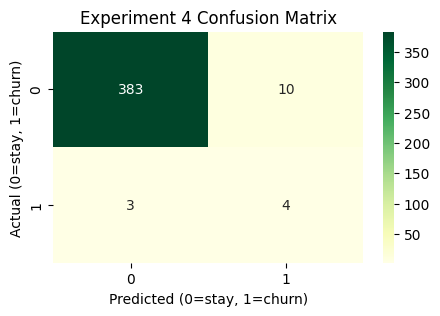


Experiment 4 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       393
           1       0.29      0.57      0.38         7

    accuracy                           0.97       400
   macro avg       0.64      0.77      0.68       400
weighted avg       0.98      0.97      0.97       400



In [7]:
# Experiment 4: Precision Tuning

model_exp4 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='tanh'),
    Dropout(0.2),  # Prevents the model from becoming too "obsessed" with specific training points
    Dense(units=8, activation='tanh'),
    Dense(units=1, activation='sigmoid')
])

# Using Nadam with a custom learning rate for better stability
custom_optimizer = Nadam(learning_rate=0.0005)
model_exp4.compile(optimizer=custom_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# We will use a weight of 1:40 (slightly lower than before to reduce "noise")
history4 = model_exp4.fit(
    X_train, y_train,
    epochs=150,
    batch_size=12,     # Middle ground batch size
    validation_split=0.2,
    class_weight={0: 1.0, 1: 40.0},
    verbose=0
)

# Evaluation
training_accuracy4 = history4.history['accuracy'][-1]
training_loss4 = history4.history['loss'][-1]
test_loss4, test_accuracy4 = model_exp4.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred4 = (model_exp4.predict(X_test) > 0.5).astype(int)

print("Experiment 4: Precision Tuning Results")
print(f"Training Accuracy: {training_accuracy4*100:.2f}%")
print(f"Training Loss:     {training_loss4:.4f}")
print(f"Testing Accuracy:  {test_accuracy4*100:.2f}%")
print(f"Testing Loss:      {test_loss4:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred4), annot=True, fmt='d', cmap='YlGn')
plt.title('Experiment 4 Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

# Classification Report
print("\nExperiment 4 Classification Report:")
print(classification_report(y_test, y_pred4))

In [10]:
# Create the data based on experiment outputs
data = {
    'Experiment': ['Baseline', 'Exp 1', 'Exp 2', 'Exp 3', 'Exp 4 '],
    'Key Changes': [
        'ReLU, Batch 32, 50 Epochs', 
        'Tanh Activation, Batch 16', 
        'Class Weights (1:10)', 
        'Weights (1:50), 200 Epochs', 
        'Nadam, Dropout, LR 0.0005'
    ],
    'Testing Accuracy': ['98.50%', '98.25%', '98.00%', '95.00%', '96.75%'],
    'Churners Caught': ['1 / 7', '1 / 7', '1 / 7', '3 / 7', '4 / 7'],
    'Result': ['Biased', 'No Change', 'Insufficient', 'High Recall', 'Best Balance']
}

df_results = pd.DataFrame(data)

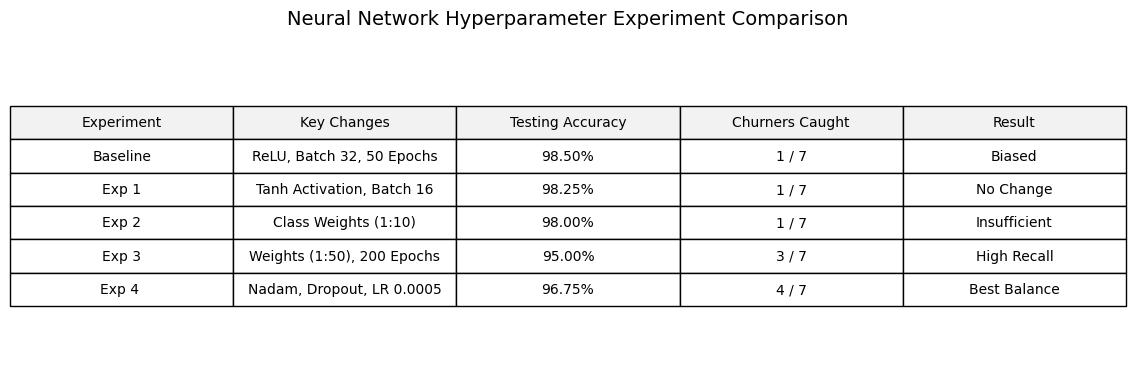

In [13]:
def save_results_table(df):
    fig, ax = plt.subplots(figsize=(12, 4)) # Adjust size as needed
    ax.axis('off')
    ax.axis('tight')

    # Create the table
    table = ax.table(cellText=df.values, 
                     colLabels=df.columns, 
                     cellLoc='center', 
                     loc='center',
                     colColours=["#f2f2f2"] * len(df.columns))
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2) # Adjusting row height and column width

    plt.title("Neural Network Hyperparameter Experiment Comparison", fontsize=14, pad=20)
    
    # Save the file to your results folder
    # Make sure you have created the 'results' folder in your directory first!
    plt.savefig('results/model_comparison_table.png', bbox_inches='tight', dpi=300)
    plt.show()

# Run the function
save_results_table(df_results)

### **Task 6: Final Reflection**

**1. What role do weights and biases play in the model?**

**Weights** act as the "importance" of each input feature; the model adjusts them during 
training to determine which factors most influence churn. 
**Biases** provide the model with an extra degree of freedom, allowing the activation function to shift so the network can produce meaningful outputs even when input values are zero or near-zero. Together, they allow the model to learn and represent complex data relationships.



**2. Why is an activation function required?**
Without **activation functions**, stacking multiple layers would still produce a linear output — no matter how deep the network is. Real-world problems like churn prediction are non-linear, meaning a straight line cannot capture the relationship between features and the target.

Activation functions like **ReLU** and **Tanh** introduce non-linearity, allowing the network to learn complex patterns. In this project, switching from **ReLU** to **Tanh** in later experiments helped the model handle the imbalanced data slightly better due to Tanh's symmetric output range.



**3. What happens when the learning rate is too high or too low?**

If the learning rate is too high, the model **overshoots** the optimal solution during training. The loss starts jumping around instead of steadily decreasing, and the model may never converge properly.

If it is too low, training becomes **very slow** and the model risks getting stuck before reaching a good solution. In Experiment 4, I switched to the **Nadam optimizer** with a learning rate of **0.0005** — lower than the default **Adam** rate — which gave the model more stable and controlled updates, contributing to the best overall result.



**4. Did your model show signs of underfitting or overfitting?**

The **baseline model underfit** the minority class significantly. Despite a testing accuracy of 98.50%, it only caught 1 out of 7 actual churners. The model took the path of least resistance by predicting the majority class almost every time, which is a classic sign of **underfitting** on the minority class in an imbalanced dataset.

**Experiment 3** pushed too far in the other direction — with extreme class weights of 1:50 and 200 epochs, the model became too aggressive and started misclassifying stayers as churners, showing signs of **overfitting** to the minority class.

**Experiment 4** found the best balance. By introducing **Dropout**, reducing the class weight to 1:40, and using a lower learning rate, the model generalised better and caught 4 out of 7 churners while maintaining a testing accuracy of **96.75%**.